In [2]:
pip install yfinance pandas numpy matplotlib

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TICKERS = ["NVDA", "AAPL", "INTC"]   # 你可以换成 2-3 个
START = "2020-01-01"
END = "2024-12-31"

def load_prices(tickers, start, end):
    df = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)["Close"]
    if isinstance(df, pd.Series):
        df = df.to_frame()
    df = df.dropna(how="all")
    return df

prices = load_prices(TICKERS, START, END)
print(prices.tail())

Ticker            AAPL       INTC        NVDA
Date                                         
2024-12-23  253.883102  20.200001  139.631805
2024-12-24  256.797180  20.400000  140.181671
2024-12-26  257.612701  20.440001  139.891739
2024-12-27  254.201385  20.299999  136.972534
2024-12-30  250.829788  19.820000  137.452393


In [ ]:
TRADING_DAYS = 252

def compute_metrics(price_series: pd.Series):
    # daily returns
    rets = price_series.pct_change().dropna()

    # annualized return (geometric)
    total_return = (price_series.iloc[-1] / price_series.iloc[0]) - 1
    n_years = len(rets) / TRADING_DAYS
    ann_return = (1 + total_return) ** (1 / n_years) - 1 if n_years > 0 else np.nan

    # annualized vol
    ann_vol = rets.std() * np.sqrt(TRADING_DAYS)

    # sharpe (rf=0)
    sharpe = (rets.mean() / rets.std()) * np.sqrt(TRADING_DAYS) if rets.std() != 0 else np.nan

    # max drawdown
    equity = (1 + rets).cumprod()
    peak = equity.cummax()
    drawdown = (equity / peak) - 1
    max_dd = drawdown.min()

    return {
        "ann_return": float(ann_return),
        "ann_vol": float(ann_vol),
        "sharpe": float(sharpe),
        "max_drawdown": float(max_dd),
        "total_return": float(total_return),
    }

metrics = []
for t in TICKERS:
    m = compute_metrics(prices[t].dropna())
    m["ticker"] = t
    metrics.append(m)

metrics_df = pd.DataFrame(metrics).set_index("ticker")
metrics_df.to_csv("metrics.csv")
print(metrics_df)

        ann_return   ann_vol    sharpe  max_drawdown  total_return
ticker                                                            
NVDA      0.876236  0.538874  1.436047     -0.663351     22.019699
AAPL      0.283132  0.316891  0.945262     -0.314273      2.464475
INTC     -0.181150  0.434701 -0.237666     -0.695732     -0.630682


In [ ]:
def plot_equity_curves(prices: pd.DataFrame, outpath="equity_curve.png"):
    rets = prices.pct_change().dropna()
    equity = (1 + rets).cumprod()  # start at 1
    plt.figure()
    for col in equity.columns:
        plt.plot(equity.index, equity[col], label=col)
    plt.title("Equity Curves (Cumulative Return)")
    plt.xlabel("Date")
    plt.ylabel("Growth of $1")
    plt.legend()
    plt.tight_layout()
    plt.savefig(outpath, dpi=200)
    plt.close()

plot_equity_curves(prices[TICKERS], "equity_curve.png")
print("Saved equity_curve.png")

Saved equity_curve.png


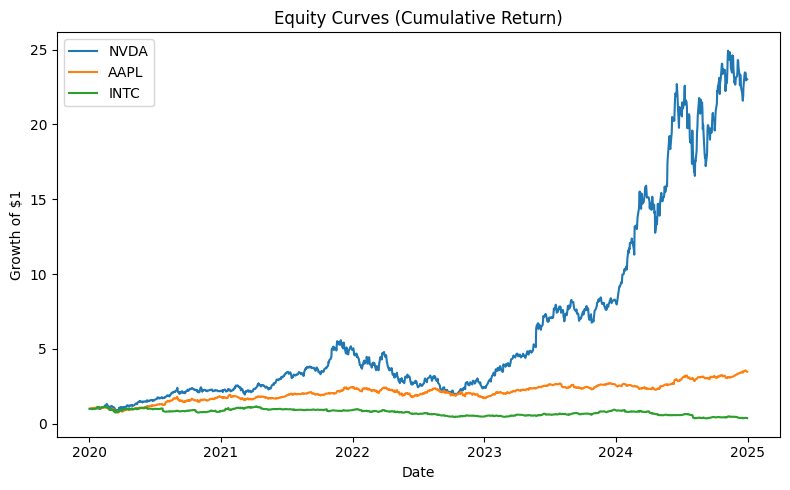

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_equity_curves(prices: pd.DataFrame):
    """
    Plot cumulative return (growth of $1) for selected tickers.
    """
    rets = prices.pct_change().dropna()
    equity = (1 + rets).cumprod()

    plt.figure(figsize=(8,5))
    for col in equity.columns:
        plt.plot(equity.index, equity[col], label=col)

    plt.title("Equity Curves (Cumulative Return)")
    plt.xlabel("Date")
    plt.ylabel("Growth of $1")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 调用
plot_equity_curves(prices[TICKERS])

In [ ]:
#
rets = prices[TICKERS].pct_change().dropna()

ann_return = rets.mean() * 252
ann_vol = rets.std() * np.sqrt(252)
sharpe = ann_return / ann_vol

cum = (1 + rets).cumprod()
rolling_max = cum.cummax()
drawdown = (cum - rolling_max) / rolling_max
max_dd = drawdown.min()

metrics_df = pd.DataFrame({
    "Annual Return": ann_return,
    "Annual Volatility": ann_vol,
    "Sharpe": sharpe,
    "Max Drawdown": max_dd
})

display(metrics_df.round(4))

# 转换成 JSON（给 LLM 用
metrics_json = metrics_df.round(4).to_dict()

import json
print("\nMetrics JSON (for LLM):")
print(json.dumps(metrics_json, indent=2))

# Consistency Check：重新手算 Sharpe
manual_sharpe = (rets.mean() / rets.std()) * np.sqrt(252)

print("\nManual Sharpe Check:")
print(manual_sharpe.round(4))

print("\nOriginal Sharpe from metrics_df:")
print(metrics_df["Sharpe"].round(4))

,Annual Return,Annual Volatility,Sharpe,Max Drawdown
Ticker,,,,
NVDA,0.7738,0.5389,1.4360,-0.6634
AAPL,0.2995,0.3169,0.9453,-0.3143
INTC,-0.1033,0.4347,-0.2377,-0.6957



Metrics JSON (for LLM):
{
  "Annual Return": {
    "NVDA": 0.7738,
    "AAPL": 0.2995,
    "INTC": -0.1033
  },
  "Annual Volatility": {
    "NVDA": 0.5389,
    "AAPL": 0.3169,
    "INTC": 0.4347
  },
  "Sharpe": {
    "NVDA": 1.436,
    "AAPL": 0.9453,
    "INTC": -0.2377
  },
  "Max Drawdown": {
    "NVDA": -0.6634,
    "AAPL": -0.3143,
    "INTC": -0.6957
  }
}

Manual Sharpe Check:
Ticker
NVDA    1.4360
AAPL    0.9453
INTC   -0.2377
dtype: float64

Original Sharpe from metrics_df:
Ticker
NVDA    1.4360
AAPL    0.9453
INTC   -0.2377
Name: Sharpe, dtype: float64


In [ ]:
metrics_json = metrics_df.round(4).to_dict(orient="index")
import json
with open("metrics.json", "w") as f:
    json.dump(metrics_json, f, indent=2)

print("Saved metrics.json")

Saved metrics.json


In [ ]:
!pip install yfinance
import yfinance as yf
ticker = yf.Ticker("NVDA")
news = ticker.news
news_text = []
for n in news[:5]:
    c = n.get("content", {})
    title = c.get("title", "")
    summary = c.get("summary", "")
    pubDate = c.get("pubDate", "")
    if title or summary:
        news_text.append(f"{pubDate} | {title} | {summary}")
print("\n\n".join(news_text))

news_text = " ".join(news_text)

2026-03-04T21:35:17Z | Earnings live: Broadcom stock edges higher as earnings beat doesn't wow investors, Okta stock climbs | The S&P 500 was on track for double-digit earnings growth, with more than half of companies having reported Q4 results so far.

2026-03-05T10:27:31Z | Why Aurora Innovation Zoomed 11% Higher in February | The autonomous truck technology developer reported significant progress in the second month of the year.

2026-03-05T10:26:07Z | Broadcom rallies as it touts more than $100 billion in AI chip sales in 2027 | Broadcom shares jumped about 7% before the bell on Thursday after the company said it ‌expects artificial intelligence chip sales to top $100 billion in ‌2027, as it pushes into a market long ruled by Nvidia.  Big Tech ​firms such as Alphabet, Microsoft, Amazon and Meta are expected to spend more than $600 billion to build AI infrastructure this year, boosting demand for chips, servers, storage and networking equipment.  Broadcom expects to ‌deliver 3 gigaw

In [ ]:
def build_news_evidence(news, k=8):
    rows = []
    for n in news[:k]:
        c = n.get("content", {})
        title = c.get("title", "")
        summary = c.get("summary", "")
        pubDate = c.get("pubDate", "")
        if title or summary:
            rows.append(f"- {pubDate} | {title} | {summary}")
    return "\n".join(rows)

evidence_text = build_news_evidence(news, k=8)
print(evidence_text)

- 2026-03-04T21:35:17Z | Earnings live: Broadcom stock edges higher as earnings beat doesn't wow investors, Okta stock climbs | The S&P 500 was on track for double-digit earnings growth, with more than half of companies having reported Q4 results so far.
- 2026-03-05T10:27:31Z | Why Aurora Innovation Zoomed 11% Higher in February | The autonomous truck technology developer reported significant progress in the second month of the year.
- 2026-03-05T10:26:07Z | Broadcom rallies as it touts more than $100 billion in AI chip sales in 2027 | Broadcom shares jumped about 7% before the bell on Thursday after the company said it ‌expects artificial intelligence chip sales to top $100 billion in ‌2027, as it pushes into a market long ruled by Nvidia.  Big Tech ​firms such as Alphabet, Microsoft, Amazon and Meta are expected to spend more than $600 billion to build AI infrastructure this year, boosting demand for chips, servers, storage and networking equipment.  Broadcom expects to ‌deliver 3 g

In [ ]:
print(news[0])

{'id': '19cd1080-a43d-4393-8ed1-77d2b30d3322', 'content': {'id': '19cd1080-a43d-4393-8ed1-77d2b30d3322', 'contentType': 'STORY', 'title': "Earnings live: Broadcom stock edges higher as earnings beat doesn't wow investors, Okta stock climbs", 'description': '', 'summary': 'The S&P 500 was on track for double-digit earnings growth, with more than half of companies having reported Q4 results so far.', 'pubDate': '2026-03-04T21:35:17Z', 'displayTime': '2026-03-05T10:25:42Z', 'isHosted': True, 'bypassModal': False, 'previewUrl': None, 'thumbnail': {'originalUrl': 'https://s.yimg.com/os/creatr-uploaded-images/2026-03/0015ac10-17f6-11f1-973f-3367362e30c8', 'originalWidth': 8256, 'originalHeight': 5504, 'caption': '', 'resolutions': [{'url': 'https://s.yimg.com/uu/api/res/1.2/dF6.F13aD5BldrKJKVFRpw--~B/aD01NTA0O3c9ODI1NjthcHBpZD15dGFjaHlvbg--/https://s.yimg.com/os/creatr-uploaded-images/2026-03/0015ac10-17f6-11f1-973f-3367362e30c8', 'width': 8256, 'height': 5504, 'tag': 'original'}, {'url': 'h

In [ ]:
import json
from datetime import datetime
from typing import List, Dict, Tuple, Union

def _to_datetime(d):
    if hasattr(d, "to_pydatetime"):
        return d.to_pydatetime()
    if isinstance(d, datetime):
        return d
    return datetime.strptime(str(d)[:10], "%Y-%m-%d")

def build_similarity_metrics_json(
    series_name: str,
    similar_points: List[Union[Dict, Tuple]],
    include_annualized: bool = True,
):
    pts = []
    for p in similar_points:
        if isinstance(p, (list, tuple)) and len(p) == 2:
            d, e = p
            pts.append({"date": str(d)[:10], "equity": float(e)})
        elif isinstance(p, dict):
            pts.append({"date": str(p["date"])[:10], "equity": float(p["equity"])})
        else:
            raise ValueError("similar_points must be list of dicts or (date, equity) tuples")

    pts.sort(key=lambda x: x["date"])

    segments = []
    for i in range(len(pts) - 1):
        d1 = _to_datetime(pts[i]["date"])
        d2 = _to_datetime(pts[i + 1]["date"])
        e1 = pts[i]["equity"]
        e2 = pts[i + 1]["equity"]

        days = (d2 - d1).days
        if days <= 0:
            raise ValueError(f"Non-positive days between {pts[i]['date']} and {pts[i+1]['date']}")

        simple_return = e2 / e1 - 1.0

        seg = {
            "segment_id": i + 1,
            "start_date": pts[i]["date"],
            "end_date": pts[i + 1]["date"],
            "days_between": days,
            "equity_start": e1,
            "equity_end": e2,
            "simple_return": simple_return,
        }

        if include_annualized:
            seg["annualized_return"] = (e2 / e1) ** (365.0 / days) - 1.0

        segments.append(seg)

    metrics_dict = {
        "series_name": series_name,
        "similar_points": pts,
        "segments": segments,
        "definitions": {
            "equity": "cumulative growth of $1",
            "simple_return": "equity_end / equity_start - 1",
            "annualized_return": "(equity_end / equity_start)^(365/days_between) - 1" if include_annualized else None,
        }
    }

    metrics_json = json.dumps(metrics_dict, indent=2)
    return metrics_dict, metrics_json



In [ ]:
def build_similarity_prompt(metrics_json: str) -> str:
    return f"""
You are a quantitative financial analyst.

STRICT OUTPUT RULES:
- Output ONLY lines that start with "Segment".
- Do NOT output thinking/reasoning/process.
- Use ONLY numbers already present in the JSON. Do NOT add external facts (no news, no events, no macro, no company info).
- If a required numeric field is missing for any segment, output ONE line starting with "Segment N:" and say exactly what is missing, then stop.

TASK:
For each item in JSON.segments, output exactly ONE line:

Segment N: [start_date -> end_date] equity: X -> Y, simple_return=..., annualized_return=... (if present). Growth: <1 short sentence describing growth using ONLY JSON numbers>. Similarity: <1 short sentence explaining why this segment is similar to other segments using ONLY JSON numbers (e.g., comparable equity multiple, return magnitude, or compounding speed)>.

JSON:
{metrics_json}
""".strip()

In [ ]:
similar_points = [
    {"date": "2021-03-15", "equity": 1.82},
    {"date": "2023-06-20", "equity": 6.75},
    {"date": "2024-11-01", "equity": 21.30},
]

metrics_dict, metrics_json = build_similarity_metrics_json(
    series_name="NVDA",
    similar_points=similar_points,
    include_annualized=True
)

prompt = build_similarity_prompt(metrics_json)

with open("prompt.txt", "w", encoding="utf-8") as f:
    f.write(prompt)

print("metrics_json length:", len(metrics_json))
print("prompt length:", len(prompt))
print("prompt.txt saved")

metrics_json length: 999
prompt length: 1859
prompt.txt saved
